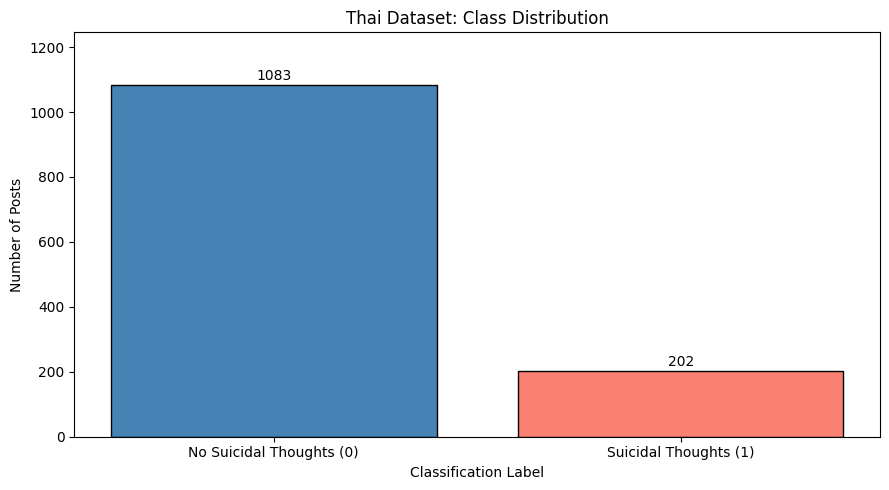

Class Distribution (%):
label
0    84.3
1    15.7
Name: count, dtype: float64


In [14]:
#Visualization 1: Thai Class Distribution

import pandas as pd
import matplotlib.pyplot as plt

#Loads the cleaned Thai dataset
df = pd.read_csv("thai_clean_full.csv")

#Counts the number of posts in each class
counts = df["label"].value_counts().reindex([0, 1], fill_value=0)

#Creates a bar chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    ["No Suicidal Thoughts (0)", "Suicidal Thoughts (1)"],
    counts.values,
    color=["steelblue", "salmon"],
    edgecolor="black"
)

#Adding labels and a title
plt.title("Thai Dataset: Class Distribution")
plt.xlabel("Classification Label")
plt.ylabel("Number of Posts")

#Displays numbers above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        int(bar.get_height()),
        ha="center"
    )

plt.ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

#Displays a summary of the statistics
print("Class Distribution (%):")
print((counts / counts.sum() * 100).round(1))


**Figure 1: Thai Dataset Class Distribution**

Figure 1 shows the distribution of classification labels in the cleaned Thai dataset. Of the 1,285 posts, 1,083 (84.3%) are labelled as having no suicidal thoughts, while 202 (15.7%) are labelled as containing suicidal thoughts. Unlike the Arabic dataset, the Thai dataset has a noticeable class imbalance, with significantly fewer positive examples. Overall, posts labelled as having no suicidal thoughts make up the majority of the cleaned dataset, outnumbering positive examples by more than five to one.

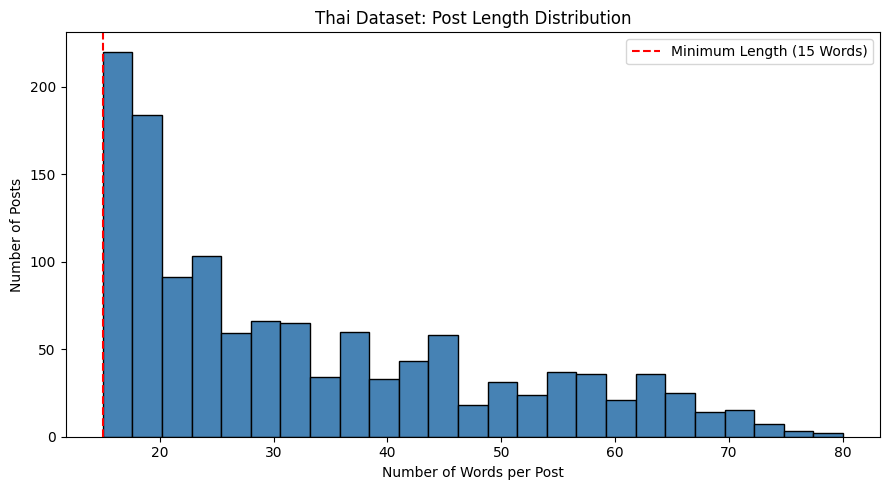

Post Length Statistics:
count    1285.000000
mean       32.633463
std        16.172030
min        15.000000
25%        19.000000
50%        27.000000
75%        44.000000
max        80.000000
Name: n_words, dtype: float64


In [15]:

#Visualization 2: Thai Post Length Distribution

#Creates the histogram
plt.figure(figsize=(9, 5))

plt.hist(
    df["n_words"],
    bins=25,
    color="steelblue",
    edgecolor="black"
)

#Shows the minimum word requirement
plt.axvline(
    x=15,
    color="red",
    linestyle="--",
    label="Minimum Length (15 Words)"
)

#Adding labels and a title
plt.title("Thai Dataset: Post Length Distribution")
plt.xlabel("Number of Words per Post")
plt.ylabel("Number of Posts")

plt.legend()
plt.tight_layout()
plt.show()

#Displays a summary of the statistics
print("Post Length Statistics:")
print(df["n_words"].describe())


**Figure 2: Thai Post Length Distribution**

Figure 2 shows the distribution of post lengths in the cleaned Thai dataset, measured by the number of words per post. All 1,285 posts meet the minimum requirement of 15 words, with an average length of approximately 32.6 words and a median of 27 words. The longest post contains 80 words. Since the average is higher than the median, this suggests that some longer posts increase the overall average. Thai does not consistently separate words using spaces, so PyThaiNLP was used during preprocessing to calculate word counts. The minimum length requirement ensures that each post has enough text to be meaningfully divided into three sections.

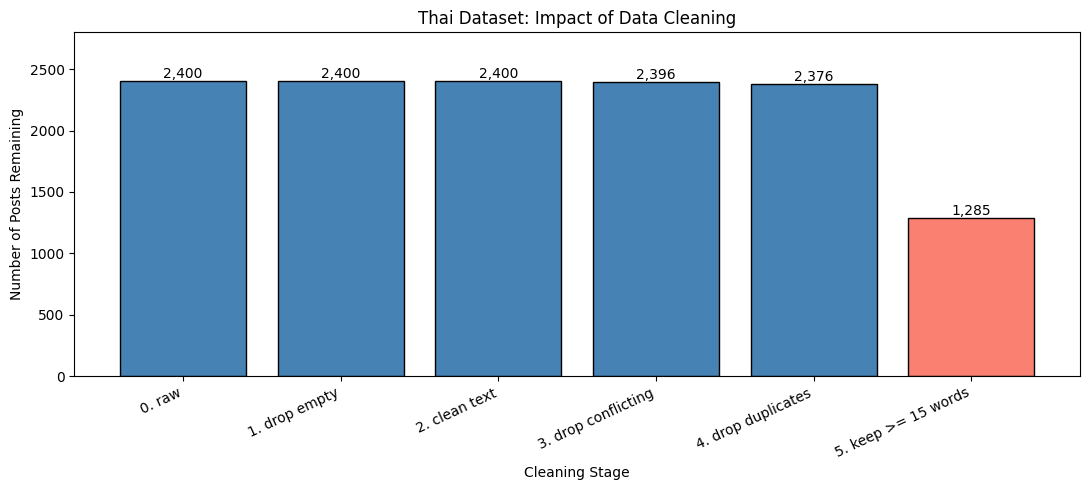

In [16]:

#Visualization 3: Impact of Data Cleaning

#Loads the Thai cleaning log
cleaning_df = pd.read_csv("thai_cleaning_log.csv")

#Selects the six cleaning stages, excluding the final balanced sample
cleaning_df = cleaning_df.iloc[:6]

#Creates the bar chart
plt.figure(figsize=(11, 5))

bars = plt.bar(
    cleaning_df["step"],
    cleaning_df["rows"],
    color=["steelblue"] * 5 + ["salmon"],
    edgecolor="black"
)

#Adding labels and a title
plt.title("Thai Dataset: Impact of Data Cleaning")
plt.xlabel("Cleaning Stage")
plt.ylabel("Number of Posts Remaining")

#Displays the number above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 25,
        f"{int(bar.get_height()):,}",
        ha="center"
    )

plt.xticks(rotation=25, ha="right")
plt.ylim(0, 2800)

plt.tight_layout()
plt.show()


**Figure 3: Impact of Data Cleaning on the Thai Dataset**

Figure 3 shows how the number of Thai posts changed throughout the data cleaning process. The original dataset contained 2,400 posts, which decreased to 2,376 after removing contradictory and duplicate entries. The largest reduction occurred when applying the minimum length requirement of 15 words, leaving 1,285 posts. Overall, approximately 46.5% of the original dataset was excluded during preprocessing. As a result, only 53.5% of the original posts remained available for the project's text splitting experiments.

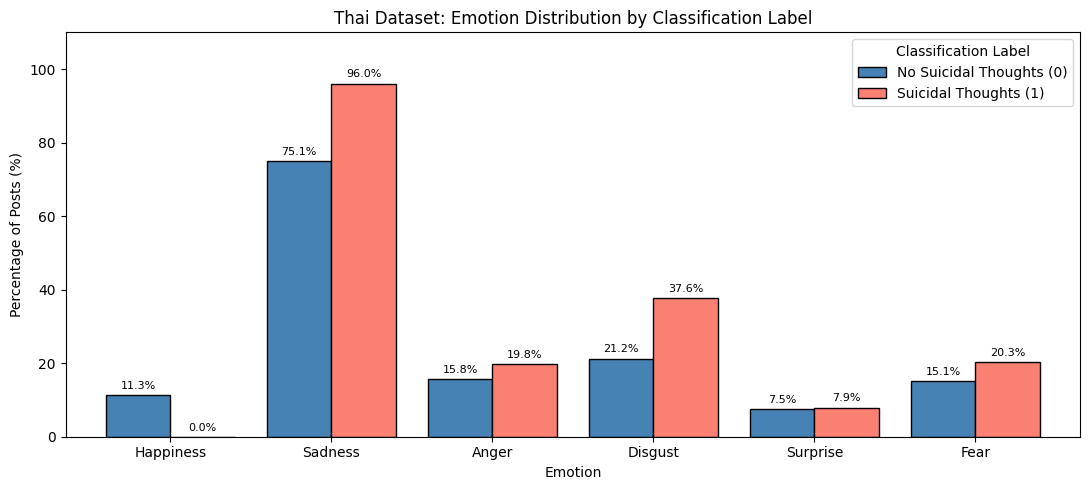

Emotion Distribution (%):
           No Suicidal Thoughts (0)  Suicidal Thoughts (1)
Happiness                      11.3                    0.0
Sadness                        75.1                   96.0
Anger                          15.8                   19.8
Disgust                        21.2                   37.6
Surprise                        7.5                    7.9
Fear                           15.1                   20.3


In [17]:

#Visualization 4: Emotion Distribution by Classification Label

#Selects only the emotion columns
emotion_columns = [
    "Happiness",
    "Sadness",
    "Anger",
    "Disgust",
    "Surprise",
    "Fear"
]

#Calculates the percentage of posts for each emotion
emotion_percentages = (
    df.groupby("label")[emotion_columns].mean() * 100
)

#Renames classification labels
emotion_percentages.index = [
    "No Suicidal Thoughts (0)",
    "Suicidal Thoughts (1)"
]

#Swaps rows and columns to compare both classification labels by emotion
emotion_percentages = emotion_percentages.T

#Creates the grouped bar chart
ax = emotion_percentages.plot(
    kind="bar",
    figsize=(11, 5),
    color=["steelblue", "salmon"],
    edgecolor="black",
    width=0.8
)

#Adding labels and a title
plt.title("Thai Dataset: Emotion Distribution by Classification Label")
plt.xlabel("Emotion")
plt.ylabel("Percentage of Posts (%)")
plt.xticks(rotation=0)
plt.legend(title="Classification Label")

#Displays percentages above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

plt.ylim(0, 110)
plt.tight_layout()
plt.show()

#Displays a summary of the statistics
print("Emotion Distribution (%):")
print(emotion_percentages.round(1))


**Figure 4: Thai Emotion Distribution by Classification Label**

Figure 4 compares the distribution of six recorded emotions across the two classification labels in the cleaned Thai dataset. Sadness is the most common emotion in both categories, appearing in 96.0% of posts labelled as containing suicidal thoughts and 75.1% of posts labelled as not containing suicidal thoughts. Disgust also appears more frequently in the positive class (37.6%) compared to the negative class (21.2%), while Fear shows a smaller difference of 20.3% compared to 15.1%. In contrast, Happiness is absent from the positive class but appears in 11.3% of negative posts. These results highlight differences in the recorded emotional characteristics of the two categories. Since posts can contain multiple emotion labels, the percentages do not necessarily add up to 100%.